# Twitter Sentiment Analysis (XGBoost)

**Objective**: Build a sentiment classifier using XGBoost — a gradient boosting model.

## Why XGBoost?

XGBoost (eXtreme Gradient Boosting) is a **gradient boosting** algorithm:
- Builds trees **sequentially** — each new tree corrects the errors of the previous ones
- Unlike Random Forest (which builds trees independently and averages), boosting focuses on hard-to-classify examples
- Consistently among the **top-performing models** on structured/tabular data
- Handles sparse data (like TF-IDF matrices) efficiently

### How It Differs from Random Forest

| Aspect | Random Forest | XGBoost |
|--------|--------------|----------|
| Strategy | Build trees independently, average | Build trees sequentially, correct errors |
| Tree depth | Deep trees (low bias, high variance) | Shallow trees (high bias, low variance) |
| Focus | Reduce variance | Reduce bias |
| Speed | Parallelizable | Sequential (but optimized) |

## Previous Models (for reference)

| Model | Features | Binary Acc | 3-Class Acc | Type |
|-------|----------|------------|-------------|------|
| Logistic Regression | TF-IDF | ~80% | ~60% | Linear |
| SVM (LinearSVC) | TF-IDF | ~80% | ~60% | Linear |
| Naive Bayes | CountVectorizer | ~75-78% | ~55-60% | Probabilistic |
| Random Forest | TF-IDF | ~75-80% | ~55-60% | Non-linear ensemble |

## Table of Contents
1. [Data Loading & Preprocessing](#1-data-loading--preprocessing)
2. [Feature Engineering (TF-IDF)](#2-feature-engineering-tf-idf)
3. [Model Training (XGBoost)](#3-model-training-xgboost)
4. [Evaluation on Test Data](#4-evaluation-on-test-data)
5. [Comparison with Previous Models](#5-comparison-with-previous-models)
6. [Export Model](#6-export-model)

In [24]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os
import time

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost
from xgboost import XGBClassifier

# Settings
pd.set_option('display.max_colwidth', 100)
%matplotlib inline

---
## 1. Data Loading & Preprocessing

Same preprocessing pipeline as all previous notebooks.

In [25]:
# Load training data
train_df = pd.read_csv(
    'trainingandtestdata/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

# Load test data
test_df = pd.read_csv(
    'trainingandtestdata/testdata.manual.2009.06.14.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

print(f"Training data: {len(train_df):,} samples")
print(f"Test data: {len(test_df)} samples")

Training data: 1,600,000 samples
Test data: 498 samples


In [26]:
def preprocess_text(text):
    """
    Clean tweet text for sentiment analysis.
    
    Same preprocessing as all previous notebooks:
    1. Lowercase
    2. Remove URLs
    3. Remove @mentions
    4. Remove # symbol (keep hashtag text)
    5. Remove special characters
    6. Normalize whitespace
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # URLs
    text = re.sub(r'@\w+', '', text)                      # @mentions
    text = re.sub(r'#', '', text)                         # # symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)               # special chars
    text = re.sub(r'\s+', ' ', text).strip()              # whitespace
    
    return text

In [27]:
# Apply preprocessing
print("Preprocessing training data (this may take a minute)...")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
train_df['label'] = train_df['sentiment'].apply(lambda x: 1 if x == 4 else 0)
train_df = train_df[train_df['clean_text'].str.len() > 0]
print(f"Training size: {len(train_df):,}")

print("\nPreprocessing test data...")
test_df['clean_text'] = test_df['text'].apply(preprocess_text)
test_df = test_df[test_df['clean_text'].str.len() > 0]
print(f"Test size: {len(test_df)}")

Preprocessing training data (this may take a minute)...
Training size: 1,596,303

Preprocessing test data...
Test size: 498


---
## 2. Feature Engineering (TF-IDF)

TF-IDF for gradient boosting — same rationale as Random Forest:
- Normalized features give cleaner split thresholds
- XGBoost handles sparse matrices efficiently

Same settings: 10k features, unigrams + bigrams.

In [28]:
# Create TF-IDF vectorizer (same settings as all previous notebooks)
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

print("Fitting TF-IDF on training data...")
X_train = tfidf.fit_transform(train_df['clean_text'])
y_train = train_df['label'].values

X_test = tfidf.transform(test_df['clean_text'])

print(f"Training matrix: {X_train.shape}")
print(f"Test matrix: {X_test.shape}")

Fitting TF-IDF on training data...
Training matrix: (1596303, 10000)
Test matrix: (498, 10000)


---
## 3. Model Training (XGBoost)

Like Random Forest, we train on a **sample** of the data to keep training time reasonable.

### Hyperparameters
- `n_estimators=300`: Number of boosting rounds (sequential trees)
- `max_depth=6`: Shallow trees (typical for boosting — each tree is a "weak learner")
- `learning_rate=0.1`: Step size — smaller = more conservative, needs more trees
- `subsample=0.8`: Use 80% of data per tree (adds randomness, reduces overfitting)
- `colsample_bytree=0.8`: Use 80% of features per tree
- `tree_method='hist'`: Fast histogram-based algorithm for large datasets

In [29]:
# Sample training data for XGBoost
SAMPLE_SIZE = 200000

np.random.seed(42)
sample_indices = np.random.choice(len(y_train), size=SAMPLE_SIZE, replace=False)
X_train_sample = X_train[sample_indices]
y_train_sample = y_train[sample_indices]

print(f"Training on {SAMPLE_SIZE:,} samples (sampled from {len(y_train):,})")
print(f"  Negative: {(y_train_sample == 0).sum():,}")
print(f"  Positive: {(y_train_sample == 1).sum():,}")

Training on 200,000 samples (sampled from 1,596,303)
  Negative: 99,465
  Positive: 100,535


In [30]:
# Train XGBoost
print("Training XGBoost (300 boosting rounds)...")
print("(This may take several minutes)\n")

start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=300,          # Number of boosting rounds
    max_depth=6,               # Shallow trees (weak learners)
    learning_rate=0.1,         # Step size
    subsample=0.8,             # 80% of data per tree
    colsample_bytree=0.8,      # 80% of features per tree
    tree_method='hist',        # Fast histogram method
    eval_metric='logloss',     # Evaluation metric
    random_state=42,
    verbosity=0                # Suppress warnings
)

xgb_model.fit(X_train_sample, y_train_sample)

train_time = time.time() - start_time
print(f"Training complete! ({train_time:.1f} seconds)")
print(f"Number of boosting rounds: {xgb_model.n_estimators}")

Training XGBoost (300 boosting rounds)...
(This may take several minutes)

Training complete! (23.4 seconds)
Number of boosting rounds: 300


In [31]:
# Feature importance from XGBoost
feature_names = tfidf.get_feature_names_out()
importances = xgb_model.feature_importances_

# Top features
top_features = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("Top 20 Most Important Features (XGBoost):")
print("=" * 45)
for word, imp in top_features[:20]:
    print(f"  {word:20} importance: {imp:.4f}")

Top 20 Most Important Features (XGBoost):
  sad                  importance: 0.0149
  thanks               importance: 0.0093
  cant wait            importance: 0.0091
  wait                 importance: 0.0088
  hate                 importance: 0.0073
  sick                 importance: 0.0064
  sucks                importance: 0.0063
  miss                 importance: 0.0061
  welcome              importance: 0.0055
  good                 importance: 0.0054
  wish                 importance: 0.0054
  not good             importance: 0.0052
  great                importance: 0.0049
  wont                 importance: 0.0048
  bad                  importance: 0.0048
  poor                 importance: 0.0048
  damn                 importance: 0.0048
  happy                importance: 0.0047
  headache             importance: 0.0046
  sorry                importance: 0.0045


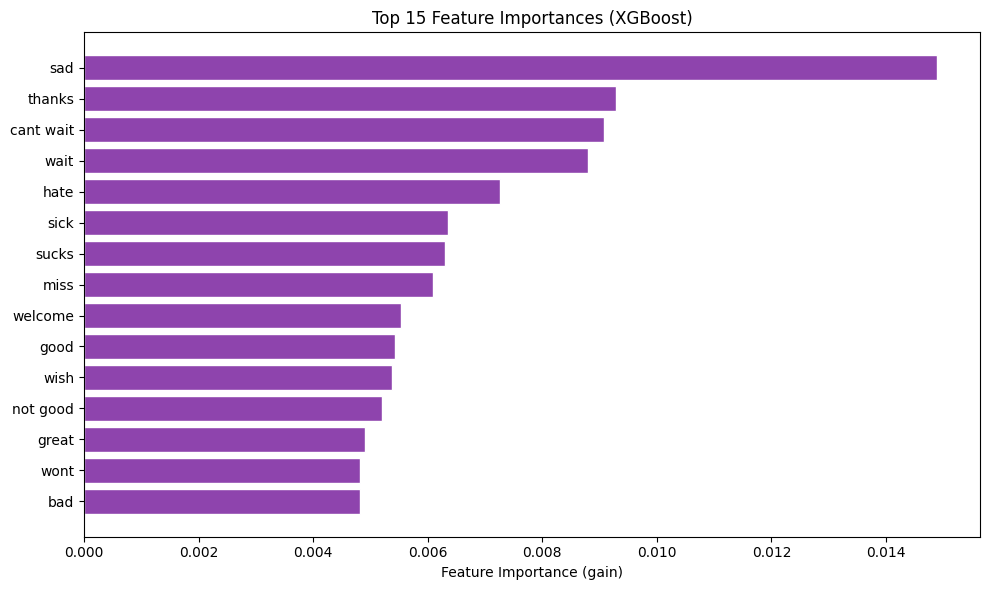

In [32]:
# Visualize top 15 feature importances
top_15 = top_features[:15]
words = [w for w, _ in top_15]
imps = [i for _, i in top_15]

plt.figure(figsize=(10, 6))
plt.barh(range(len(words)), imps, color='#8e44ad', edgecolor='white')
plt.yticks(range(len(words)), words)
plt.xlabel('Feature Importance (gain)')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Evaluation on Test Data

Same evaluation approach as previous models:
- Probability thresholds for neutral class
- P(positive) > 0.6 → positive
- P(positive) < 0.4 → negative
- 0.4 ≤ P(positive) ≤ 0.6 → neutral

In [33]:
# Define thresholds (same as all previous models)
POSITIVE_THRESHOLD = 0.6
NEGATIVE_THRESHOLD = 0.4

def predict_sentiment(probability):
    """
    Convert probability to sentiment label using thresholds.
    """
    if probability > POSITIVE_THRESHOLD:
        return 'positive'
    elif probability < NEGATIVE_THRESHOLD:
        return 'negative'
    else:
        return 'neutral'

In [34]:
# Get predictions on test data
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]  # P(positive)
y_pred_xgb = [predict_sentiment(p) for p in y_proba_xgb]

# Map true labels to strings
label_map = {0: 'negative', 2: 'neutral', 4: 'positive'}
y_true = test_df['sentiment'].map(label_map).values

# Store predictions in dataframe
test_df['predicted_xgb'] = y_pred_xgb
test_df['probability_xgb'] = y_proba_xgb
test_df['true_label'] = y_true

In [35]:
# Overall accuracy (3-class)
accuracy_3class_xgb = accuracy_score(y_true, y_pred_xgb)
print(f"Overall Accuracy (3-class): {accuracy_3class_xgb:.2%}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_xgb, labels=['negative', 'neutral', 'positive']))

Overall Accuracy (3-class): 54.22%

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.45      0.57       177
     neutral       0.37      0.53      0.44       139
    positive       0.59      0.64      0.61       182

    accuracy                           0.54       498
   macro avg       0.58      0.54      0.54       498
weighted avg       0.60      0.54      0.55       498



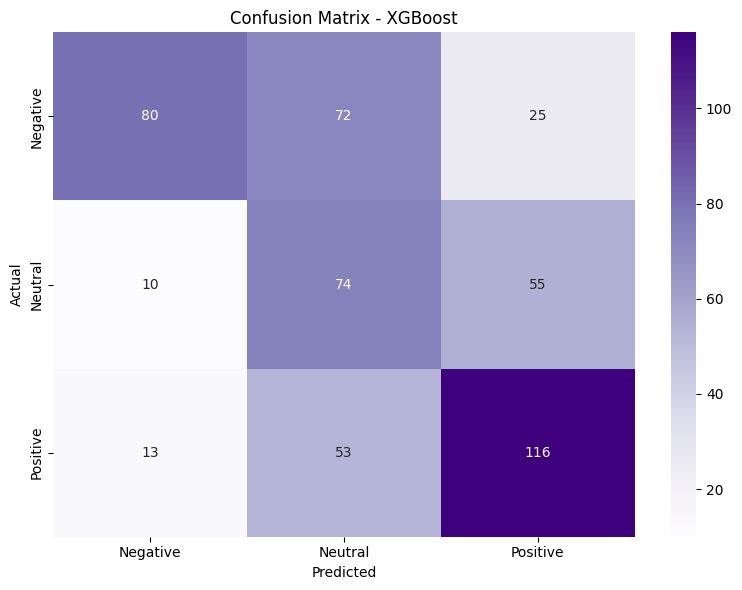

In [36]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_xgb, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()

In [37]:
# Accuracy by class
print("Accuracy by Class (XGBoost):")
print("=" * 40)
for label in ['negative', 'neutral', 'positive']:
    subset = test_df[test_df['true_label'] == label]
    correct = (subset['true_label'] == subset['predicted_xgb']).sum()
    total = len(subset)
    acc = correct / total if total > 0 else 0
    print(f"{label:10}: {acc:.2%} ({correct}/{total})")

Accuracy by Class (XGBoost):
negative  : 45.20% (80/177)
neutral   : 53.24% (74/139)
positive  : 63.74% (116/182)


In [38]:
# Binary accuracy (excluding neutral from test)
binary_test = test_df[test_df['true_label'] != 'neutral']
binary_pred = binary_test['probability_xgb'].apply(lambda p: 'positive' if p >= 0.5 else 'negative')
binary_acc_xgb = accuracy_score(binary_test['true_label'], binary_pred)

print(f"Binary Accuracy (pos/neg only): {binary_acc_xgb:.2%}")
print(f"(Evaluated on {len(binary_test)} samples, excluding neutral)")

Binary Accuracy (pos/neg only): 75.77%
(Evaluated on 359 samples, excluding neutral)


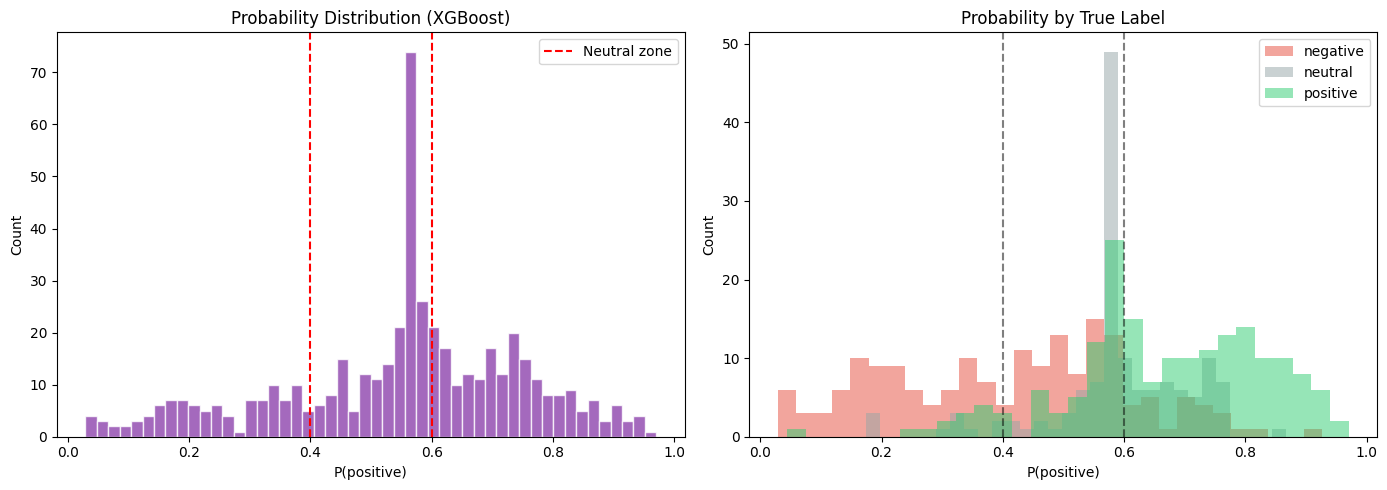

In [39]:
# Probability distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of P(positive) for all test samples
axes[0].hist(y_proba_xgb, bins=50, color='#8e44ad', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.4, color='red', linestyle='--', label='Neutral zone')
axes[0].axvline(x=0.6, color='red', linestyle='--')
axes[0].set_xlabel('P(positive)')
axes[0].set_ylabel('Count')
axes[0].set_title('Probability Distribution (XGBoost)')
axes[0].legend()

# Distribution by true label
for label, color in [('negative', '#e74c3c'), ('neutral', '#95a5a6'), ('positive', '#2ecc71')]:
    mask = y_true == label
    axes[1].hist(y_proba_xgb[mask], bins=30, alpha=0.5, label=label, color=color)
axes[1].axvline(x=0.4, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.6, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('P(positive)')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability by True Label')
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
# Show some predictions
print("Sample Predictions (XGBoost):")
print("=" * 80)

samples = test_df.sample(10, random_state=42)
for _, row in samples.iterrows():
    status = "OK" if row['true_label'] == row['predicted_xgb'] else "X"
    print(f"[{status}] {row['text'][:60]}...")
    print(f"    True: {row['true_label']:8} | Pred: {row['predicted_xgb']:8} | P(pos): {row['probability_xgb']:.2f}")
    print()

Sample Predictions (XGBoost):
[OK] getting ready to test out some burger receipes this weekend....
    True: positive | Pred: positive | P(pos): 0.91

[X] Back when I worked for Nike we had one fav word : JUST DO IT...
    True: positive | Pred: neutral  | P(pos): 0.57

[X] @MMBarnhill yay, glad you got the phone! Still, damn you, AT...
    True: negative | Pred: positive | P(pos): 0.69

[OK] waiting in line at safeway....
    True: neutral  | Pred: neutral  | P(pos): 0.57

[OK] reading on my new Kindle2!...
    True: positive | Pred: positive | P(pos): 0.67

[OK] Safeway offering mobile coupons http://bit.ly/ONH7w...
    True: neutral  | Pred: neutral  | P(pos): 0.57

[OK] Rocawear Heads to China, Building 300 Stores  - http://tinyu...
    True: neutral  | Pred: neutral  | P(pos): 0.57

[X] Bill Simmons in conversation with Malcolm Gladwell http://bi...
    True: neutral  | Pred: positive | P(pos): 0.73

[OK] @ atebits I just finished watching your Stanford iPhone Clas...
    True: po

---
## 5. Comparison with Previous Models

Train LR and SVM on the same data for a direct comparison.

In [41]:
# Train Logistic Regression for comparison (on full data)
print("Training Logistic Regression for comparison...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train, y_train)

y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = [predict_sentiment(p) for p in y_proba_lr]
print("Done!")

Training Logistic Regression for comparison...
Done!


In [42]:
# Train SVM for comparison (on full data)
print("Training SVM with probability calibration...")
print("(This may take a few minutes)\n")
base_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=3)
svm_model.fit(X_train, y_train)

y_proba_svm = svm_model.predict_proba(X_test)[:, 1]
y_pred_svm = [predict_sentiment(p) for p in y_proba_svm]
print("Done!")

Training SVM with probability calibration...
(This may take a few minutes)

Done!


In [43]:
# Compare all models

# 3-class accuracy
acc_xgb_3class = accuracy_score(y_true, y_pred_xgb)
acc_lr_3class = accuracy_score(y_true, y_pred_lr)
acc_svm_3class = accuracy_score(y_true, y_pred_svm)

# Binary accuracy
binary_mask = test_df['true_label'] != 'neutral'
binary_labels = test_df.loc[binary_mask, 'true_label']

acc_xgb_binary = accuracy_score(
    binary_labels,
    test_df.loc[binary_mask, 'probability_xgb'].apply(lambda p: 'positive' if p >= 0.5 else 'negative')
)
acc_lr_binary = accuracy_score(
    binary_labels,
    ['positive' if p >= 0.5 else 'negative' for p in y_proba_lr[binary_mask]]
)
acc_svm_binary = accuracy_score(
    binary_labels,
    ['positive' if p >= 0.5 else 'negative' for p in y_proba_svm[binary_mask]]
)

print("Model Comparison:")
print("=" * 65)
print(f"{'Metric':<25} {'XGBoost':>12} {'Log. Reg.':>12} {'SVM':>12}")
print("-" * 65)
print(f"{'Features':<25} {'TF-IDF':>12} {'TF-IDF':>12} {'TF-IDF':>12}")
print(f"{'Training data':<25} {'200k sample':>12} {'Full 1.6M':>12} {'Full 1.6M':>12}")
print(f"{'3-class accuracy':<25} {acc_xgb_3class:>12.2%} {acc_lr_3class:>12.2%} {acc_svm_3class:>12.2%}")
print(f"{'Binary accuracy':<25} {acc_xgb_binary:>12.2%} {acc_lr_binary:>12.2%} {acc_svm_binary:>12.2%}")

Model Comparison:
Metric                         XGBoost    Log. Reg.          SVM
-----------------------------------------------------------------
Features                        TF-IDF       TF-IDF       TF-IDF
Training data              200k sample    Full 1.6M    Full 1.6M
3-class accuracy                54.22%       58.84%       58.03%
Binary accuracy                 75.77%       81.06%       80.78%


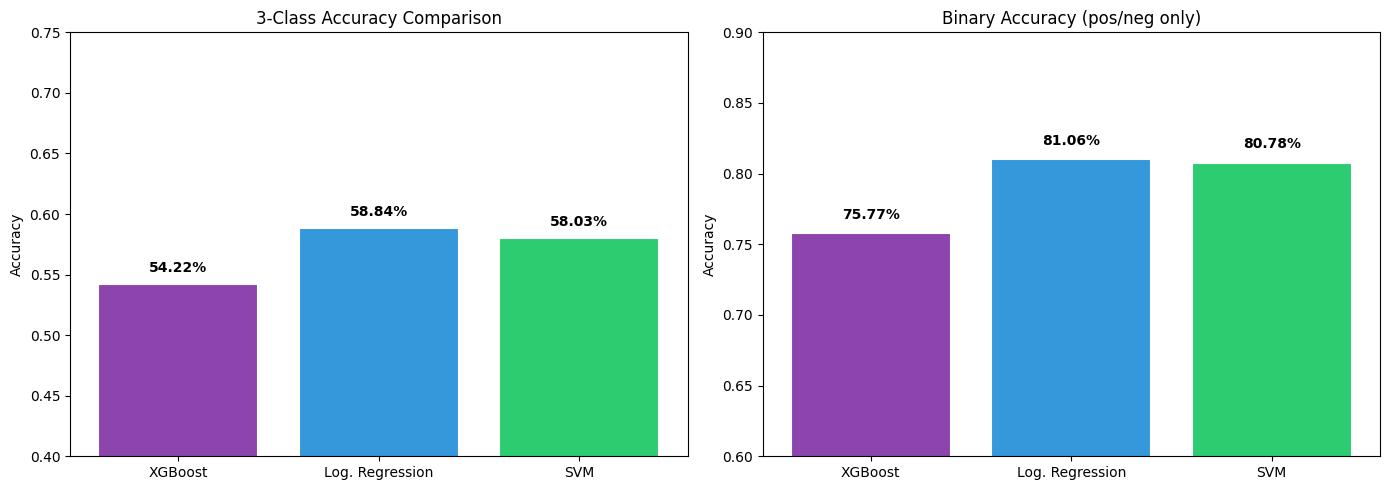

In [44]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['XGBoost', 'Log. Regression', 'SVM']
colors = ['#8e44ad', '#3498db', '#2ecc71']

# 3-class accuracy
acc_3class = [acc_xgb_3class, acc_lr_3class, acc_svm_3class]
bars1 = axes[0].bar(models, acc_3class, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('3-Class Accuracy Comparison')
axes[0].set_ylim(0.4, 0.75)
for bar, v in zip(bars1, acc_3class):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Binary accuracy
acc_binary = [acc_xgb_binary, acc_lr_binary, acc_svm_binary]
bars2 = axes[1].bar(models, acc_binary, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Binary Accuracy (pos/neg only)')
axes[1].set_ylim(0.6, 0.9)
for bar, v in zip(bars2, acc_binary):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Comparison Summary

| Model | Type | Strategy | Strengths | Limitations |
|-------|------|----------|-----------|-------------|
| **Logistic Regression** | Linear | Minimize log-loss | Fast, interpretable | Linear only |
| **SVM** | Linear | Maximize margin | Good generalization | Needs calibration |
| **Naive Bayes** | Probabilistic | Bayes' theorem | Fastest | Independence assumption |
| **Random Forest** | Ensemble (bagging) | Average many trees | Reduces variance | High memory |
| **XGBoost** | Ensemble (boosting) | Correct errors sequentially | Often best accuracy | Prone to overfitting if not tuned |

**Key Observations**:
1. **Boosting vs Bagging**: XGBoost focuses computational effort on hard examples, while Random Forest treats all examples equally
2. **Shallow vs Deep trees**: XGBoost uses shallow trees (depth 6) that individually are weak, but collectively are strong
3. **Both tree models were trained on 200k samples** — linear models still benefit from seeing all 1.6M examples

---
## 6. Export Model

In [45]:
# Save XGBoost model (commented out)
# os.makedirs('models', exist_ok=True)
# joblib.dump(tfidf, 'models/vectorizer_xgb.joblib')
# joblib.dump(xgb_model, 'models/model_xgb.joblib')
# print("XGBoost model saved!")

print("Note: Model saving is commented out.")
print("Uncomment the lines above to save the XGBoost model.")

Note: Model saving is commented out.
Uncomment the lines above to save the XGBoost model.


In [46]:
# Test inference
def evaluate_xgb(text):
    """
    Full inference pipeline for XGBoost.
    """
    clean = preprocess_text(text)
    if not clean:
        return {'sentiment': 'neutral', 'confidence': 0.0, 'probability': 0.5}
    
    vec = tfidf.transform([clean])
    prob = xgb_model.predict_proba(vec)[0][1]  # P(positive)
    
    if prob > POSITIVE_THRESHOLD:
        sentiment = 'positive'
        confidence = prob
    elif prob < NEGATIVE_THRESHOLD:
        sentiment = 'negative'
        confidence = 1 - prob
    else:
        sentiment = 'neutral'
        confidence = 1 - abs(prob - 0.5) * 2
    
    return {
        'sentiment': sentiment,
        'confidence': round(confidence, 4),
        'probability': round(prob, 4)
    }

# Test with same examples
test_texts = [
    "I love this product!",
    "This is terrible.",
    "The meeting is at 3pm.",
]

print("XGBoost Predictions:")
print("=" * 60)
for text in test_texts:
    result = evaluate_xgb(text)
    print(f"'{text}'")
    print(f"  -> {result}")
    print()

XGBoost Predictions:
'I love this product!'
  -> {'sentiment': 'positive', 'confidence': np.float32(0.8052), 'probability': np.float32(0.8052)}

'This is terrible.'
  -> {'sentiment': 'neutral', 'confidence': np.float32(0.8352), 'probability': np.float32(0.4176)}

'The meeting is at 3pm.'
  -> {'sentiment': 'neutral', 'confidence': np.float32(0.8571), 'probability': np.float32(0.5714)}



---
## Summary

### What We Built
- **Model**: TF-IDF (10k features, bigrams) + XGBoost (300 boosting rounds)
- **Training**: 200k tweets (sampled from 1.6M)
- **Test**: 498 manually labeled tweets (includes neutral)

### Key Takeaways

1. **Gradient boosting is sequential** — each tree learns from the mistakes of the previous trees
2. **Shallow trees, strong ensemble** — individual trees are weak (depth 6), but 300 of them together are powerful
3. **XGBoost is the industry standard** for structured data — used in most Kaggle competition winners
4. **Regularization matters** — `subsample`, `colsample_bytree`, and `learning_rate` all prevent overfitting

### All Models So Far

| # | Model | Notebook | Features | Type |
|---|-------|----------|----------|------|
| 1 | Logistic Regression | `sentiment_analysis_logistic_regression.ipynb` | TF-IDF | Linear |
| 2 | SVM (LinearSVC) | `sentiment_analysis_svm.ipynb` | TF-IDF | Linear |
| 3 | Naive Bayes | `sentiment_analysis_naive_bayes.ipynb` | CountVectorizer | Probabilistic |
| 4 | Random Forest | `sentiment_analysis_random_forest.ipynb` | TF-IDF | Non-linear (bagging) |
| 5 | XGBoost | `sentiment_analysis_xgboost.ipynb` | TF-IDF | Non-linear (boosting) |